In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
GTE_DIR=os.environ["GTE_DIR"]
from glaciation_time_estimator.auxiliary_func.config_reader import read_config

In [ ]:
config = read_config(
    os.path.join('/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/config_n2o.yaml'))
analyze_year=True
# years=[2007,2008,2009,2010,2011,2012,2013,2014,2015]
years = [year for year in range(2007, 2016)]
glac_threshold=0.4
global global_rmse
global_rmse = config["Global_sqrt_mse"]
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
# temperature_palette = ['#eff3ff','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
temperature_palette = ['#f1eef6','#d0d1e6','#a6bddb','#74a9cf','#2b8cbe','#045a8d']
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
temperature_palette = ["#0d0d0f",'#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']


In [3]:
temp_or = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Multiyear_analysis","temp_occurance_rate.csv"))
pole_temp_or =pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Multiyear_analysis","pole_temp_occurance_rate.csv"))
pole_temp_or_glac_possible = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Multiyear_analysis","pole_temp_occurance_rate_glac_possible.csv"))
pole_temp_season_or = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Multiyear_analysis","pole_temp_season_occurance_rate.csv"))
pole_temp_season_or_glac_possible = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Multiyear_analysis","pole_temp_season_occurance_rate_glac_possible.csv"))

# temp_or["Occurance rate"] *= 100
pole_temp_or["Occurance rate"] *= 100
pole_temp_or_glac_possible['Occurance rate']*= 100
pole_temp_season_or["Occurance rate"] *= 100
pole_temp_season_or_glac_possible['Occurance rate']*= 100

In [4]:
pole_temp_or

,Unnamed: 0,Hemisphere,min_temp,Occurance rate,year
0,0,North,-36,9.902444,2007
1,1,South,-36,10.785365,2007
2,2,North,-30,7.220691,2007
3,3,South,-30,5.427187,2007
4,4,North,-24,4.449587,2007
...,...,...,...,...,...
103,103,South,-18,1.868481,2015
104,104,North,-12,0.655112,2015
105,105,South,-12,0.615746,2015
106,106,North,-6,0.000000,2015


North
South
North
South
North
South
North
South
North
South
North
South
North
South
North
South
North
South


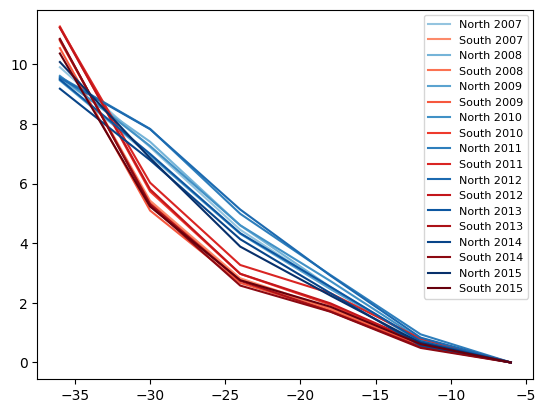

In [9]:
i=0
groups = pole_temp_or.groupby(["year","Hemisphere"])
n_groups = round(len(groups)/2)
# Generate two palettes from the Reds and Blues colormaps:
temperature_palette_north = plt.cm.Blues(np.linspace(0.4, 1, n_groups))
temperature_palette_south =  plt.cm.Reds(np.linspace(0.4, 1, n_groups))
for list in groups:
    Hemisphere= list[0][1]
    print(Hemisphere)
    if Hemisphere == "North":
        plt.plot(list[1]["min_temp"], list[1]["Occurance rate"], color=temperature_palette_north[int(i/2)], label=f"{Hemisphere} {int(2007+int(i)/2)}")
    if Hemisphere == "South":
        plt.plot(list[1]["min_temp"], list[1]["Occurance rate"], color=temperature_palette_south[int(i/2)], label=f"{Hemisphere} {int(2007+int(i)/2)}")
    i+=1
plt.legend(loc='upper right', fontsize=8)
    

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# First, determine how many distinct (year, Hemisphere) groups you have:
groups = pole_temp_or.groupby(["year", "Hemisphere"])
n_groups = len(groups)

# # Generate two palettes from the Reds and Blues colormaps:
# temperature_palette_north = plt.cm.Reds(np.linspace(0.4, 1, n_groups))
# temperature_palette_south = plt.cm.Blues(np.linspace(0.4, 1, n_groups))

# # Now plot, pulling colors from those palettes in order:
# i = 0
# for (year, hemi), df_grp in groups:
#     if hemi == "North":
#         plt.plot(df_grp["min_temp"],
#                  df_grp["Occurance rate"],
#                  color=temperature_palette_north[i],
#                  label=f"{hemi} {year}")
#     elif hemi == "South":          # fixed typo from "Sounth" → "South"
#         plt.plot(df_grp["min_temp"],
#                  df_grp["Occurance rate"],
#                  color=temperature_palette_south[i],
#                  label=f"{hemi} {year}")
#     i += 1

# plt.xlabel("Minimum Temperature")
# plt.ylabel("Occurrence Rate")
# plt.legend(ncol=2, fontsize="small")
# plt.show()


In [47]:
or_list = -temp_or[temp_or['min_temp']==-24].values[0,1:]
or_list

array([-3.53718304, -3.64714438, -3.45052857, -3.72833853, -4.06273601,
       -3.98564364, -3.44686595, -3.2910717 , -3.27911727])

In [23]:
import pymannkendall as pkm

In [49]:
pkm.pre_whitening_modification_test(or_list, alpha=0.05)

Modified_Mann_Kendall_Test_PreWhitening_Approach(trend='no trend', h=False, p=0.38647623077123283, z=0.8660254037844386, Tau=0.2857142857142857, s=8.0, var_s=65.33333333333333, slope=0.033708491310959585, intercept=-3.672017003811918)

In [24]:
temp_or[pole_temp_or["Hemisphere"]=="North"]

/tmp/ipykernel_33324/71120718.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  temp_or[pole_temp_or["Hemisphere"]=="North"]


,min_temp,2007,2008,2009,2010,2011
0,-36,10.483330,10.342348,10.121308,10.648339,10.623724
2,-24,3.537183,3.647144,3.450529,3.728339,4.062736
4,-12,0.671137,0.645124,0.653977,0.704925,0.880806


The glaciation occurance rate at each temperature range in the two hemispheres

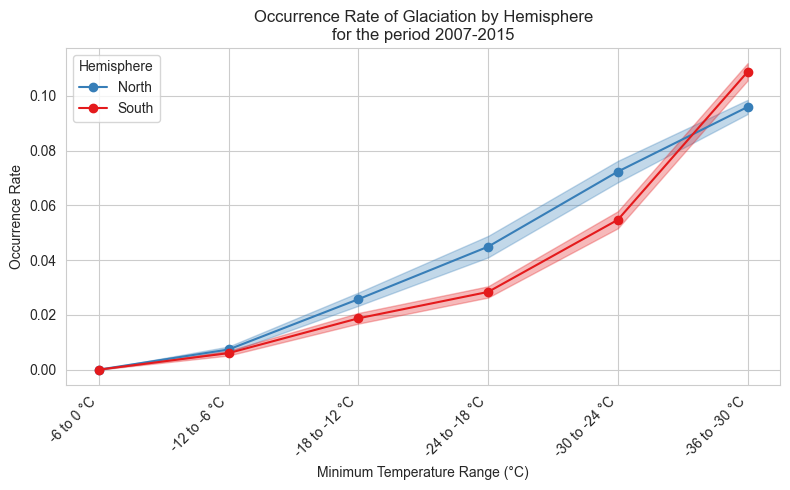

In [16]:
result_std = pole_temp_or.groupby(['min_temp',"Hemisphere"])['Occurance rate'].std()
result_mean = pole_temp_or.groupby(['min_temp',"Hemisphere"])['Occurance rate'].mean()

# Prepare DataFrame
df_mean = result_mean.reset_index().rename(columns={'Occurance rate': 'mean'})
df_std  = result_std .reset_index().rename(columns={'Occurance rate': 'std'})
df = pd.merge(df_mean, df_std, on=['min_temp', 'Hemisphere'])

# Compute range strings and midpoints
df['range_str'] = df['min_temp'].apply(lambda t: f"{t} to {t+6} °C")
df['midpoint']  = df['min_temp'] + 3  # midpoint of each 6° bin

# Establish the categorical ordering of ranges
order = (
    df[['midpoint', 'range_str']]
      .drop_duplicates()
      .sort_values('midpoint')         # from coldest (smallest min_temp) to warmest
)
midpoints = order['midpoint'].tolist()
labels     = order['range_str'].tolist()

# Plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = plt.gca()
i=0
for hemisphere, grp in df.groupby('Hemisphere'):
    grp = grp.sort_values('midpoint')
    ax.plot(grp['midpoint'], grp['mean'], marker='o', label=hemisphere,color=classifiacation_palette[(i+1)%2])
    ax.fill_between(
        grp['midpoint'],
        grp['mean'] - grp['std'],
        grp['mean'] + grp['std'],
        color=classifiacation_palette[(i+1)%2],
        alpha=0.3
    )
    i+=1


# Tick at each midpoint, labeled by the range
ax.set_xticks(midpoints)
ax.set_xticklabels(labels, rotation=45, ha='right')

# Invert so coldest (smallest midpoint) is on the right
ax.invert_xaxis()

ax.set_xlabel('Minimum Temperature Range (°C)')
ax.set_ylabel('Occurrence Rate')
ax.set_title(f'Occurrence Rate of Glaciation by Hemisphere\nfor the period {min(years)}-{max(years)}')
ax.legend(title='Hemisphere')
plt.tight_layout()
plt.show()


The glaciation occurance rate at each temperature range in the two hemispheres

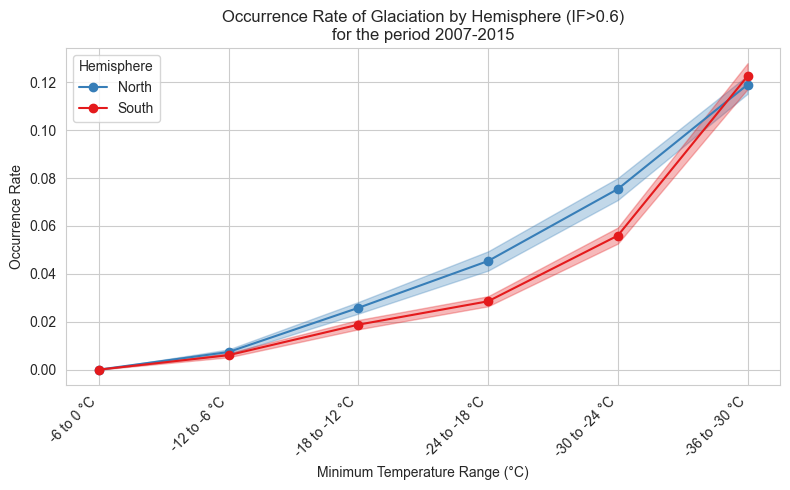

In [19]:
result_std = pole_temp_or_glac_possible.groupby(['min_temp',"Hemisphere"])['Occurance rate'].std()
result_mean = pole_temp_or_glac_possible.groupby(['min_temp',"Hemisphere"])['Occurance rate'].mean()

# Prepare DataFrame
df_mean = result_mean.reset_index().rename(columns={'Occurance rate': 'mean'})
df_std  = result_std .reset_index().rename(columns={'Occurance rate': 'std'})
df = pd.merge(df_mean, df_std, on=['min_temp', 'Hemisphere'])

# Compute range strings and midpoints
df['range_str'] = df['min_temp'].apply(lambda t: f"{t} to {t+6} °C")
df['midpoint']  = df['min_temp'] + 3  # midpoint of each 6° bin

# Establish the categorical ordering of ranges
order = (
    df[['midpoint', 'range_str']]
      .drop_duplicates()
      .sort_values('midpoint')         # from coldest (smallest min_temp) to warmest
)
midpoints = order['midpoint'].tolist()
labels     = order['range_str'].tolist()

# Plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = plt.gca()
i=0
for hemisphere, grp in df.groupby('Hemisphere'):
    grp = grp.sort_values('midpoint')
    ax.plot(grp['midpoint'], grp['mean'], marker='o', label=hemisphere,color=classifiacation_palette[(i+1)%2])
    ax.fill_between(
        grp['midpoint'],
        grp['mean'] - grp['std'],
        grp['mean'] + grp['std'],
        color=classifiacation_palette[(i+1)%2],
        alpha=0.3
    )
    i+=1


# Tick at each midpoint, labeled by the range
ax.set_xticks(midpoints)
ax.set_xticklabels(labels, rotation=45, ha='right')

# Invert so coldest (smallest midpoint) is on the right
ax.invert_xaxis()

ax.set_xlabel('Minimum Temperature Range (°C)')
ax.set_ylabel('Occurrence Rate')
ax.set_title(f'Occurrence Rate of Glaciation by Hemisphere (IF>0.6)\nfor the period {min(years)}-{max(years)}')
ax.legend(title='Hemisphere')
plt.tight_layout()
plt.show()


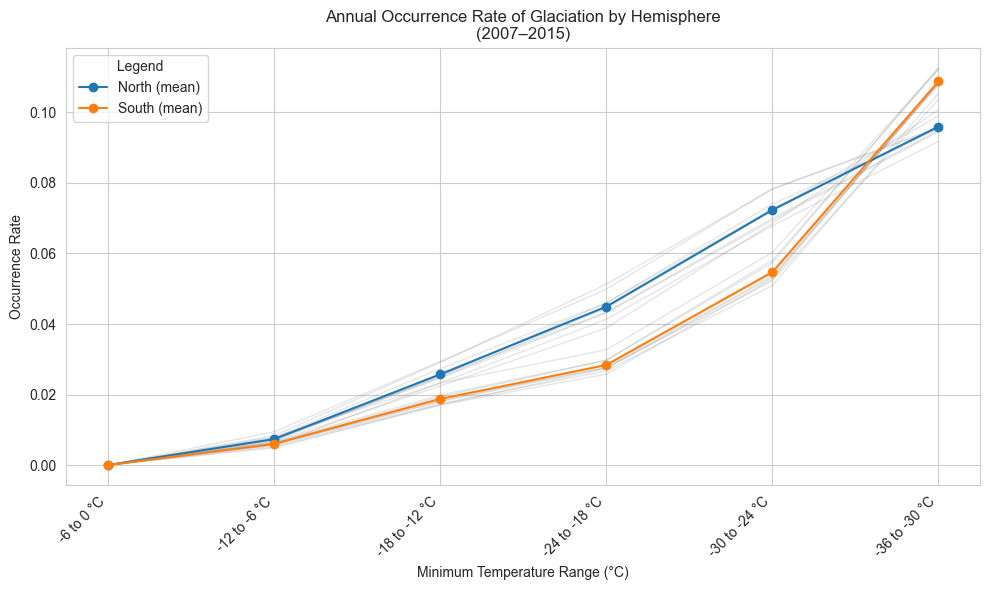

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming pole_temp_or is already defined in the environment

# Compute annual means by year, temperature bin, and hemisphere
annual = (
    pole_temp_or
    .groupby(['year', 'min_temp', 'Hemisphere'])['Occurance rate']
    .mean()
    .reset_index()
    .rename(columns={'Occurance rate': 'annual_rate'})
)
annual['midpoint'] = annual['min_temp'] + 3

# Compute aggregated mean across all years for reference
agg_mean = (
    pole_temp_or
    .groupby(['min_temp', 'Hemisphere'])['Occurance rate']
    .mean()
    .reset_index()
    .rename(columns={'Occurance rate': 'mean_rate'})
)
agg_mean['midpoint'] = agg_mean['min_temp'] + 3

# Prepare x-axis ticks and labels
order = (
    annual[['midpoint', 'min_temp']]
    .drop_duplicates()
    .sort_values('midpoint')
)
midpoints = order['midpoint'].tolist()
labels = [f"{t} to {t+6} °C" for t in order['min_temp']]

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each year's curve in transparent gray
for hemi in annual['Hemisphere'].unique():
    hemi_data = annual[annual['Hemisphere'] == hemi]
    for yr in sorted(hemi_data['year'].unique()):
        year_data = hemi_data[hemi_data['year'] == yr].sort_values('midpoint')
        ax.plot(
            year_data['midpoint'],
            year_data['annual_rate'],
            color='gray',
            alpha=0.2,
            linewidth=1
        )

# Overlay aggregated mean curves
for hemi in agg_mean['Hemisphere'].unique():
    mean_data = agg_mean[agg_mean['Hemisphere'] == hemi].sort_values('midpoint')
    ax.plot(
        mean_data['midpoint'],
        mean_data['mean_rate'],
        marker='o',
        label=f"{hemi} (mean)"
    )

# Configure axes
ax.set_xticks(midpoints)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.invert_xaxis()  # Coldest on the right
ax.set_xlabel('Minimum Temperature Range (°C)')
ax.set_ylabel('Occurrence Rate')
years = sorted(pole_temp_or['year'].unique())
ax.set_title(f'Annual Occurrence Rate of Glaciation by Hemisphere\n({min(years)}–{max(years)})')
ax.legend(title='Legend')

plt.tight_layout()
plt.show()


In [54]:
pole_temp_season_or_glac_possible

,Unnamed: 0,Hemisphere,min_temp,proportion,year
0,0,North,Season,DJF,2007
1,1,North,Season,JJA,2007
2,2,North,Season,MAM,2007
3,3,North,Season,SON,2007
4,4,South,Season,DJF,2007
...,...,...,...,...,...
499,499,North,-6,0.0,2015
500,500,South,-6,0.0,2015
501,501,South,-6,0.0,2015
502,502,South,-6,0.0,2015


In [57]:
north_over

,Hemisphere,mean,std
min_temp,,,
-36,North,0.095965,0.002587
-30,North,0.072351,0.003914
-24,North,0.044921,0.003916
-18,North,0.025732,0.002406
-12,North,0.007361,0.001079
-6,North,0.000000,0.000000


/tmp/ipykernel_33324/3618135131.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


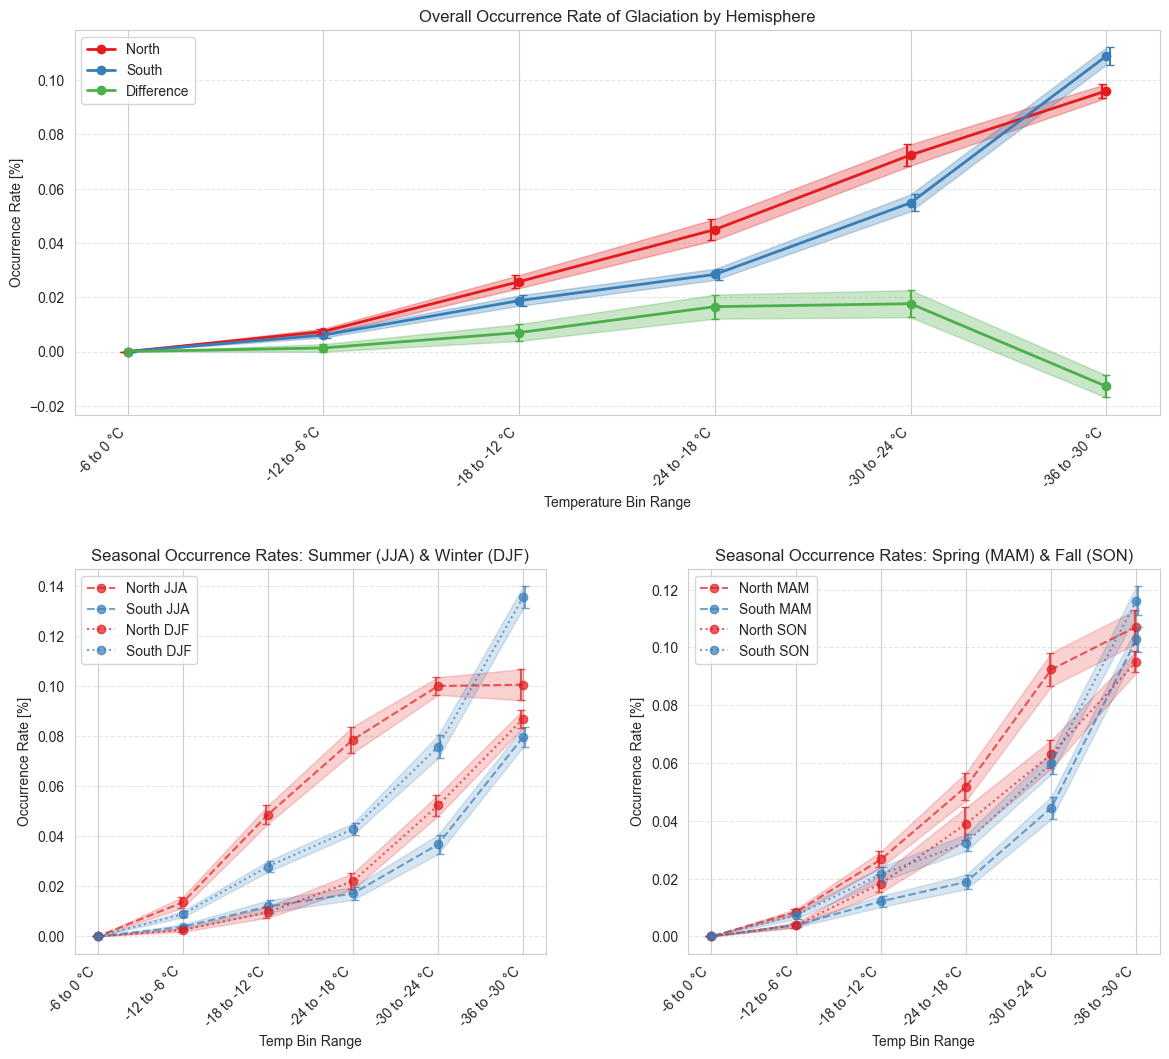

In [58]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# Assuming pole_temp_or and pole_temp_season_or are loaded in the environment,
# as well as classifiacation_palette and GTE_DIR.

# 1. Compute overall occurrence rates (mean and std across years)
overall = pole_temp_or.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere, each season
seasonal = pole_temp_season_or.groupby(['Season', 'min_temp', 'Hemisphere'])['Occurance rate'] \
                              .agg(['mean', 'std']).reset_index()
# Helper to extract series
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season'] == season) & (seasonal['Hemisphere'] == hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

# Seasons to plot
seasons = ['JJA', 'DJF', 'MAM', 'SON']
seas_pairs = [('JJA', 'DJF'), ('MAM', 'SON')]

# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 3. Create figure with GridSpec
fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.4, wspace=0.3)

# Top: overall
ax1 = fig.add_subplot(gs[0, :])
# Plot mean lines
ax1.plot(x, north_over['mean'], marker='o', label='North', 
         color=classifiacation_palette[0], linewidth=2)
ax1.plot(x, south_over['mean'], marker='o', label='South', 
         color=classifiacation_palette[1], linewidth=2)
# Difference
diff_mean = north_over['mean'] - south_over['mean']
diff_std = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax1.plot(x, diff_mean, marker='o', label='Difference', 
         color=classifiacation_palette[2], linewidth=2)

# Error bars
ax1.errorbar(x_north, north_over['mean'], yerr=north_over['std'], 
             color=classifiacation_palette[0], capsize=3, linestyle='')
ax1.errorbar(x_south, south_over['mean'], yerr=south_over['std'], 
             color=classifiacation_palette[1], capsize=3, linestyle='')
ax1.errorbar(x, diff_mean, yerr=diff_std, 
             color=classifiacation_palette[2], capsize=3, linestyle='')

ax1.set_xticks(x)
ax1.set_xticklabels(bin_labels, rotation=45, ha='right')
ax1.invert_xaxis()
ax1.set_xlabel("Temperature Bin Range")
ax1.set_ylabel("Occurrence Rate [%]")
ax1.set_title("Overall Occurrence Rate of Glaciation by Hemisphere")
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Bottom left: JJA & DJF
ax2 = fig.add_subplot(gs[1, 0])
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.plot(x, mn_n, linestyle=style, marker='o', label=f"North {season}", 
             color=classifiacation_palette[0], alpha=0.7)
    ax2.errorbar(x_north, mn_n, yerr=sd_n, capsize=3, linestyle='', color=classifiacation_palette[0], alpha=0.7)
    ax2.plot(x, mn_s, linestyle=style, marker='o', label=f"South {season}", 
             color=classifiacation_palette[1], alpha=0.7)
    ax2.errorbar(x_south, mn_s, yerr=sd_s, capsize=3, linestyle='', color=classifiacation_palette[1], alpha=0.7)

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right')
ax2.invert_xaxis()
ax2.set_xlabel("Temp Bin Range")
ax2.set_ylabel("Occurrence Rate [%]")
ax2.set_title("Seasonal Occurrence Rates: Summer (JJA) & Winter (DJF)")
ax2.legend(loc='upper left')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Bottom right: MAM & SON
ax3 = fig.add_subplot(gs[1, 1])
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax3.plot(x, mn_n, linestyle=style, marker='o', label=f"North {season}", 
             color=classifiacation_palette[0], alpha=0.7)
    ax3.errorbar(x_north, mn_n, yerr=sd_n, capsize=3, linestyle='', color=classifiacation_palette[0], alpha=0.7)
    ax3.plot(x, mn_s, linestyle=style, marker='o', label=f"South {season}", 
             color=classifiacation_palette[1], alpha=0.7)
    ax3.errorbar(x_south, mn_s, yerr=sd_s, capsize=3, linestyle='', color=classifiacation_palette[1], alpha=0.7)

ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right')
ax3.invert_xaxis()
ax3.set_xlabel("Temp Bin Range")
ax3.set_ylabel("Occurrence Rate [%]")
ax3.set_title("Seasonal Occurrence Rates: Spring (MAM) & Fall (SON)")
ax3.legend(loc='upper left')
ax3.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
# plt.savefig(f"{GTE_DIR}/seasonal_occurrence_rates.png", dpi=300)
# --- Top subplot: overall ---
# instead of ax1.errorbar(...)
ax1.fill_between(
    x,
    north_over['mean'] - north_over['std'],
    north_over['mean'] + north_over['std'],
    color=classifiacation_palette[0],
    alpha=0.3
)
ax1.fill_between(
    x,
    south_over['mean'] - south_over['std'],
    south_over['mean'] + south_over['std'],
    color=classifiacation_palette[1],
    alpha=0.3
)
ax1.fill_between(
    x,
    diff_mean - diff_std,
    diff_mean + diff_std,
    color=classifiacation_palette[2],
    alpha=0.3
)

# --- Bottom‐left subplot: JJA & DJF ---
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    # North band
    ax2.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0],
        alpha=0.2
    )
    # South band
    ax2.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1],
        alpha=0.2
    )

# --- Bottom‐right subplot: MAM & SON ---
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    # North band
    ax3.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0],
        alpha=0.2
    )
    # South band
    ax3.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1],
        alpha=0.2
    )

plt.show()


In [110]:
pole_temp_or_glac_possible

,Unnamed: 0,Hemisphere,min_temp,Occurance rate,year
0,0,North,-36,12.161692,2007
1,1,South,-36,12.072033,2007
2,2,North,-30,7.510561,2007
3,3,South,-30,5.541574,2007
4,4,North,-24,4.486779,2007
...,...,...,...,...,...
103,103,South,-18,1.871339,2015
104,104,North,-12,0.655144,2015
105,105,South,-12,0.615769,2015
106,106,North,-6,0.000000,2015


In [ ]:
# assume your DataFrame is called df

1-st.norm.cdf(diff_df.groupby('min_temp')['diff'].mean() / diff_df.groupby('min_temp')['diff'].std())


Hemisphere         North      South
year min_temp                      
2007 -36       12.161692  12.072033
     -30        7.510561   5.541574
     -24        4.486779   2.836883
     -18        2.491464   1.816524
     -12        0.743698   0.580109
     -6         0.000000   0.000000
2008 -36       11.784524  12.095282
     -30        7.719042   5.472814
     -24        4.642047   2.781414
     -18        2.536689   1.802779
     -12        0.680076   0.596884
     -6         0.000000   0.000000
2009 -36       11.455387  11.763417
     -30        7.177109   5.200941
     -24        4.351762   2.681827
     -18        2.467425   1.740841
     -12        0.717364   0.564835
     -6         0.000000   0.000000
2010 -36       12.043310  12.880025
     -30        7.583445   5.873930
     -24        4.648324   2.988685
     -18        2.738310   1.939972
     -12        0.771480   0.613610
     -6         0.000000   0.000000
2011 -36       12.319025  13.008526
     -30        8.238866   6

array([8.08022076e-01, 0.00000000e+00, 7.56512408e-10, 5.03608971e-06,
       5.58005884e-03,            nan])

Hemisphere         North      South
year min_temp                      
2007 -36       12.161692  12.072033
     -30        7.510561   5.541574
     -24        4.486779   2.836883
     -18        2.491464   1.816524
     -12        0.743698   0.580109
     -6         0.000000   0.000000
2008 -36       11.784524  12.095282
     -30        7.719042   5.472814
     -24        4.642047   2.781414
     -18        2.536689   1.802779
     -12        0.680076   0.596884
     -6         0.000000   0.000000
2009 -36       11.455387  11.763417
     -30        7.177109   5.200941
     -24        4.351762   2.681827
     -18        2.467425   1.740841
     -12        0.717364   0.564835
     -6         0.000000   0.000000
2010 -36       12.043310  12.880025
     -30        7.583445   5.873930
     -24        4.648324   2.988685
     -18        2.738310   1.939972
     -12        0.771480   0.613610
     -6         0.000000   0.000000
2011 -36       12.319025  13.008526
     -30        8.238866   6

/tmp/ipykernel_33324/1861151023.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


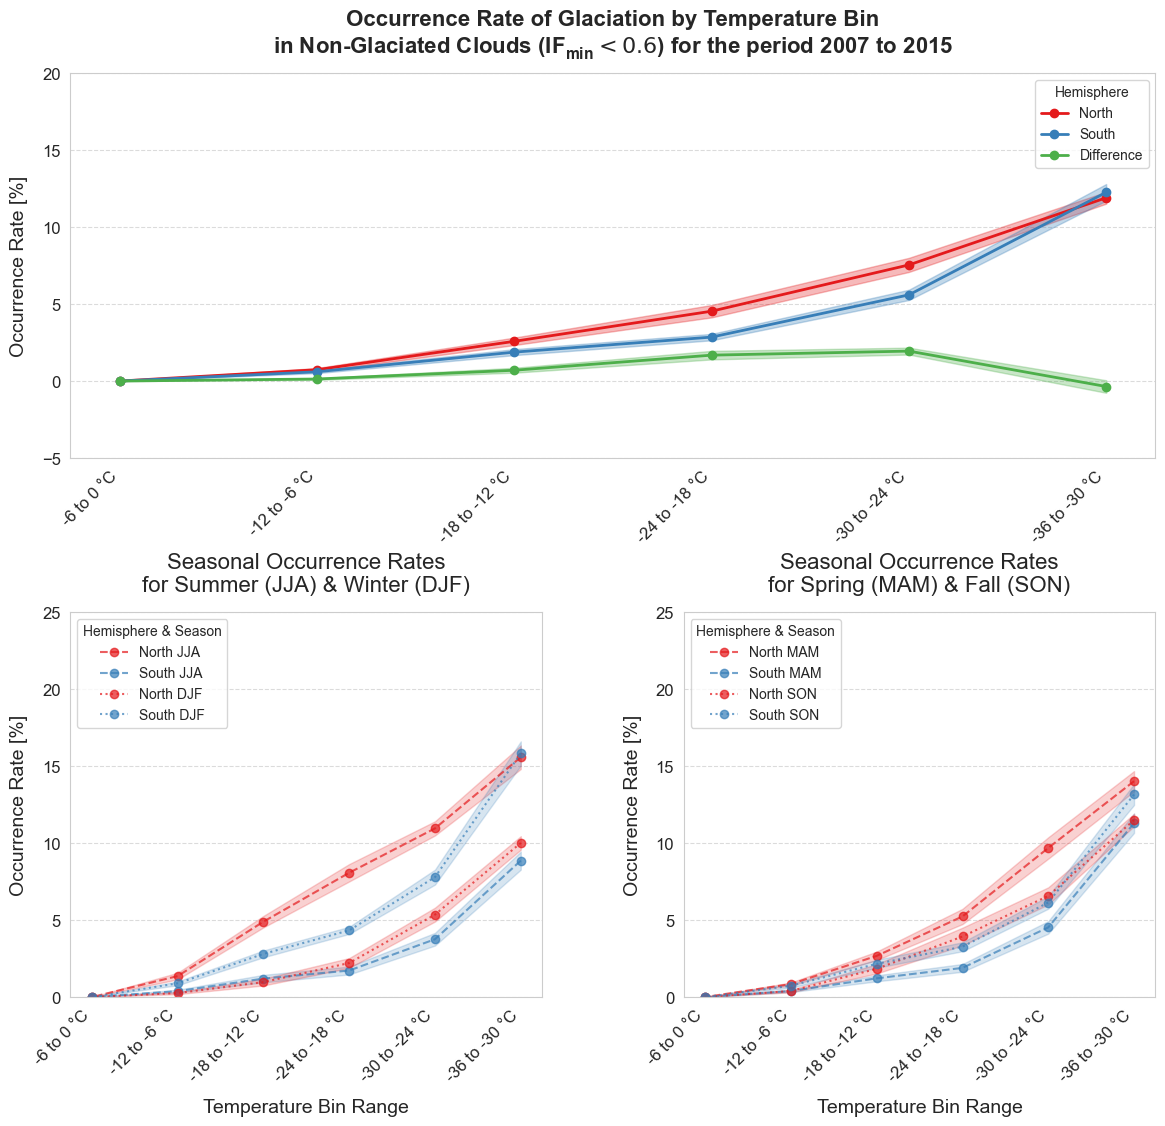

In [124]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

import scipy.stats as st
# 1. Pivot so that each (year, min_temp) has North and South in separate columns
pivot = pole_temp_or_glac_possible.pivot(index=['year', 'min_temp'],
                 columns='Hemisphere',
                 values='Occurance rate')
print(pivot)
# 2. Compute the difference (North minus South)
pivot['diff'] = pivot['North'] - pivot['South']

# 3. (Optional) Bring it back to a flat DataFrame
diff_df = pivot['diff'].reset_index()


# Assuming the following are already defined:
# pole_temp_or_glac_possible, pole_temp_season_or_glac_possible,
# classifiacation_palette, years

# 1. Compute overall occurrence rates (mean and std across years)
overall = (
    pole_temp_or_glac_possible
    .groupby(['min_temp', 'Hemisphere'])['Occurance rate']
    .agg(['mean', 'std'])
    .reset_index()
)
north_over = overall[overall['Hemisphere']=='North'].set_index('min_temp')
south_over = overall[overall['Hemisphere']=='South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere & season
seasonal = (
    pole_temp_season_or_glac_possible
    .groupby(['Season','min_temp','Hemisphere'])['Occurance rate']
    .agg(['mean','std'])
    .reset_index()
)
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season']==season)&(seasonal['Hemisphere']==hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

seas_pairs = [('JJA','DJF'), ('MAM','SON')]

# 3. Prepare x-axis bins
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 4. Create figure
fig = plt.figure(figsize=(14,12))
gs = gridspec.GridSpec(2,2, height_ratios=[1,1], hspace=0.4, wspace=0.3)

# Top: overall
ax1 = fig.add_subplot(gs[0,:])
ax1.plot(x, north_over['mean'], marker='o', label='North',
         color=classifiacation_palette[0], linewidth=2)
ax1.plot(x, south_over['mean'], marker='o', label='South',
         color=classifiacation_palette[1], linewidth=2)

diff_mean = north_over['mean'] - south_over['mean']
diff_std  = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax1.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=2)

# Replace errorbars with filled error bands
ax1.fill_between(x,
                 north_over['mean'] - north_over['std'],
                 north_over['mean'] + north_over['std'],
                 color=classifiacation_palette[0], alpha=0.3)
ax1.fill_between(x,
                 south_over['mean'] - south_over['std'],
                 south_over['mean'] + south_over['std'],
                 color=classifiacation_palette[1], alpha=0.3)
ax1.fill_between(x,
                 diff_df.groupby('min_temp')['diff'].mean() - diff_df.groupby('min_temp')['diff'].std(),
                 diff_df.groupby('min_temp')['diff'].mean() + diff_df.groupby('min_temp')['diff'].std(),
                 color=classifiacation_palette[2], alpha=0.3)

ax1.set_xticks(x)
ax1.set_xticklabels(bin_labels, rotation=45, ha='right')
ax1.invert_xaxis()
ax1.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax1.set_title(
    f"Occurrence Rate of Glaciation by Temperature Bin\n"
    r"in Non-Glaciated Clouds ($\mathregular{{IF_{{min}}}}<0.6$) "
    f"for the period {min(years)} to {max(years)}",
    fontsize=16, pad=15, fontweight="bold"
)

ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', labelsize=12, rotation=45)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_ylim(-5, 20)
ax1.legend(title="Hemisphere")

# Bottom-left: JJA & DJF
ax2 = fig.add_subplot(gs[1,0])
for season, style in zip(seas_pairs[0], ['--',':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')

    ax2.plot(x, mn_n, linestyle=style, marker='o',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7)
    ax2.plot(x, mn_s, linestyle=style, marker='o',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7)

    ax2.fill_between(x,
                     mn_n - sd_n,
                     mn_n + sd_n,
                     color=classifiacation_palette[0], alpha=0.2)
    ax2.fill_between(x,
                     mn_s - sd_s,
                     mn_s + sd_s,
                     color=classifiacation_palette[1], alpha=0.2)

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right')
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax2.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax2.set_title("Seasonal Occurrence Rates\nfor Summer (JJA) & Winter (DJF)",
              fontsize=16, pad=15)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, 25)
ax2.legend(title="Hemisphere & Season", loc="upper left")

# Bottom-right: MAM & SON
ax3 = fig.add_subplot(gs[1,1])
for season, style in zip(seas_pairs[1], ['--',':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')

    ax3.plot(x, mn_n, linestyle=style, marker='o',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7)
    ax3.plot(x, mn_s, linestyle=style, marker='o',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7)

    ax3.fill_between(x,
                     mn_n - sd_n,
                     mn_n + sd_n,
                     color=classifiacation_palette[0], alpha=0.2)
    ax3.fill_between(x,
                     mn_s - sd_s,
                     mn_s + sd_s,
                     color=classifiacation_palette[1], alpha=0.2)

ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right')
ax3.invert_xaxis()
ax3.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax3.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax3.set_title("Seasonal Occurrence Rates\nfor Spring (MAM) & Fall (SON)",
              fontsize=16, pad=15)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.tick_params(axis='x', labelsize=12, rotation=45)
ax3.tick_params(axis='y', labelsize=12)
ax3.set_ylim(0, 25)
ax3.legend(title="Hemisphere & Season", loc="upper left")

# --- Top: overall ---
# ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.xaxis.grid(False)    # ← turn off vertical grid

# --- Bottom-left: JJA & DJF ---
# ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.xaxis.grid(False)    # ← turn off vertical grid

# --- Bottom-right: MAM & SON ---
# ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.xaxis.grid(False)    # ← turn off vertical grid


plt.tight_layout()
plt.savefig(f"{GTE_DIR}/Result_graphs/Multiyear_analysis/Seasonal_occ_rates_non_glac.png", dpi=300)
# plt.show()


Hemisphere         North      South
year min_temp                      
2007 -36        9.902444  10.785365
     -30        7.220691   5.427187
     -24        4.449587   2.823052
     -18        2.484720   1.813936
     -12        0.743626   0.580076
     -6         0.000000   0.000000
2008 -36        9.528375  10.810230
     -30        7.402934   5.357355
     -24        4.596888   2.766976
     -18        2.529138   1.799918
     -12        0.679957   0.596806
     -6         0.000000   0.000000
2009 -36        9.456826  10.541389
     -30        6.938630   5.095891
     -24        4.315120   2.669252
     -18        2.462080   1.738531
     -12        0.717297   0.564812
     -6         0.000000   0.000000
2010 -36        9.611457  11.268241
     -30        7.259360   5.735749
     -24        4.600676   2.970935
     -18        2.731036   1.936465
     -12        0.771413   0.613566
     -6         0.000000   0.000000
2011 -36        9.579088  11.235743
     -30        7.834016   6

/tmp/ipykernel_33324/991684146.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


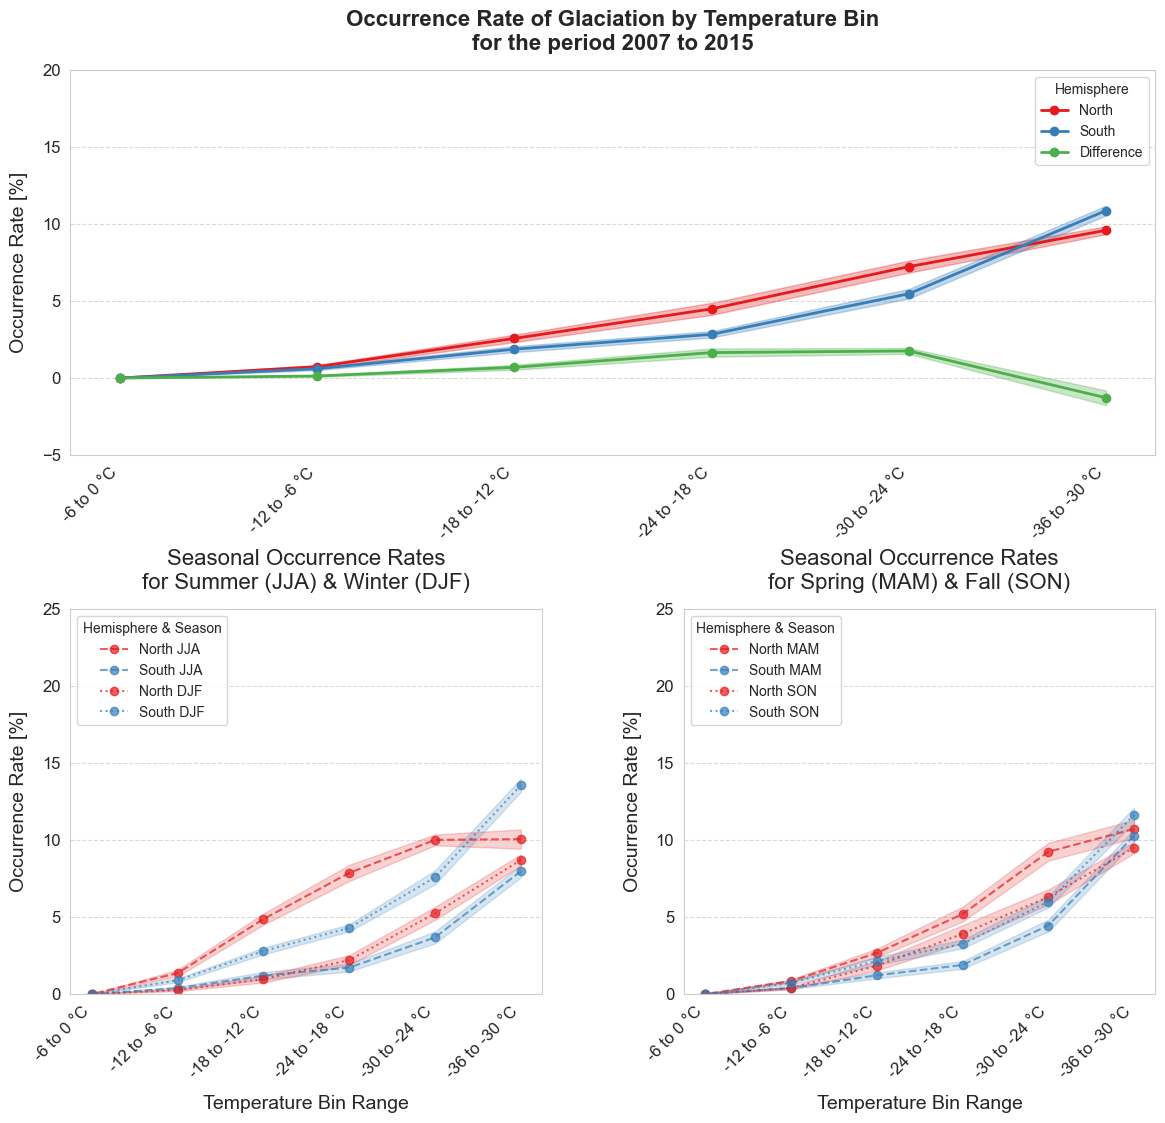

In [123]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

import scipy.stats as st
# 1. Pivot so that each (year, min_temp) has North and South in separate columns
pivot = pole_temp_or.pivot(index=['year', 'min_temp'],
                 columns='Hemisphere',
                 values='Occurance rate')
print(pivot)
# 2. Compute the difference (North minus South)
pivot['diff'] = pivot['North'] - pivot['South']

# 3. (Optional) Bring it back to a flat DataFrame
diff_df = pivot['diff'].reset_index()


# Assuming the following are already defined:
# pole_temp_or_glac_possible, pole_temp_season_or_glac_possible,
# classifiacation_palette, years

# 1. Compute overall occurrence rates (mean and std across years)
overall = (
    pole_temp_or
    .groupby(['min_temp', 'Hemisphere'])['Occurance rate']
    .agg(['mean', 'std'])
    .reset_index()
)
north_over = overall[overall['Hemisphere']=='North'].set_index('min_temp')
south_over = overall[overall['Hemisphere']=='South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere & season
seasonal = (
    pole_temp_season_or
    .groupby(['Season','min_temp','Hemisphere'])['Occurance rate']
    .agg(['mean','std'])
    .reset_index()
)
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season']==season)&(seasonal['Hemisphere']==hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

seas_pairs = [('JJA','DJF'), ('MAM','SON')]

# 3. Prepare x-axis bins
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 4. Create figure
fig = plt.figure(figsize=(14,12))
gs = gridspec.GridSpec(2,2, height_ratios=[1,1], hspace=0.4, wspace=0.3)

# Top: overall
ax1 = fig.add_subplot(gs[0,:])
ax1.plot(x, north_over['mean'], marker='o', label='North',
         color=classifiacation_palette[0], linewidth=2)
ax1.plot(x, south_over['mean'], marker='o', label='South',
         color=classifiacation_palette[1], linewidth=2)

diff_mean = north_over['mean'] - south_over['mean']
diff_std  = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax1.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=2)

# Replace errorbars with filled error bands
ax1.fill_between(x,
                 north_over['mean'] - north_over['std'],
                 north_over['mean'] + north_over['std'],
                 color=classifiacation_palette[0], alpha=0.3)
ax1.fill_between(x,
                 south_over['mean'] - south_over['std'],
                 south_over['mean'] + south_over['std'],
                 color=classifiacation_palette[1], alpha=0.3)
ax1.fill_between(x,
                 diff_df.groupby('min_temp')['diff'].mean() - diff_df.groupby('min_temp')['diff'].std(),
                 diff_df.groupby('min_temp')['diff'].mean() + diff_df.groupby('min_temp')['diff'].std(),
                 color=classifiacation_palette[2], alpha=0.3)

ax1.set_xticks(x)
ax1.set_xticklabels(bin_labels, rotation=45, ha='right')
ax1.invert_xaxis()
ax1.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax1.set_title(
    f"Occurrence Rate of Glaciation by Temperature Bin\n"
    f"for the period {min(years)} to {max(years)}",
    fontsize=16, pad=15, fontweight="bold"
)

ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', labelsize=12, rotation=45)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_ylim(-5, 20)
ax1.legend(title="Hemisphere")

# Bottom-left: JJA & DJF
ax2 = fig.add_subplot(gs[1,0])
for season, style in zip(seas_pairs[0], ['--',':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')

    ax2.plot(x, mn_n, linestyle=style, marker='o',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7)
    ax2.plot(x, mn_s, linestyle=style, marker='o',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7)

    ax2.fill_between(x,
                     mn_n - sd_n,
                     mn_n + sd_n,
                     color=classifiacation_palette[0], alpha=0.2)
    ax2.fill_between(x,
                     mn_s - sd_s,
                     mn_s + sd_s,
                     color=classifiacation_palette[1], alpha=0.2)

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right')
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax2.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax2.set_title("Seasonal Occurrence Rates\nfor Summer (JJA) & Winter (DJF)",
              fontsize=16, pad=15)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, 25)
ax2.legend(title="Hemisphere & Season", loc="upper left")

# Bottom-right: MAM & SON
ax3 = fig.add_subplot(gs[1,1])
for season, style in zip(seas_pairs[1], ['--',':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')

    ax3.plot(x, mn_n, linestyle=style, marker='o',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7)
    ax3.plot(x, mn_s, linestyle=style, marker='o',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7)

    ax3.fill_between(x,
                     mn_n - sd_n,
                     mn_n + sd_n,
                     color=classifiacation_palette[0], alpha=0.2)
    ax3.fill_between(x,
                     mn_s - sd_s,
                     mn_s + sd_s,
                     color=classifiacation_palette[1], alpha=0.2)

ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right')
ax3.invert_xaxis()
ax3.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax3.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax3.set_title("Seasonal Occurrence Rates\nfor Spring (MAM) & Fall (SON)",
              fontsize=16, pad=15)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.tick_params(axis='x', labelsize=12, rotation=45)
ax3.tick_params(axis='y', labelsize=12)
ax3.set_ylim(0, 25)
ax3.legend(title="Hemisphere & Season", loc="upper left")

# --- Top: overall ---
# ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.xaxis.grid(False)    # ← turn off vertical grid

# --- Bottom-left: JJA & DJF ---
# ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.xaxis.grid(False)    # ← turn off vertical grid

# --- Bottom-right: MAM & SON ---
# ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.xaxis.grid(False)    # ← turn off vertical grid


plt.tight_layout()
plt.savefig(f"{GTE_DIR}/Result_graphs/Multiyear_analysis/Seasonal_occ_rates.png", dpi=300)
# plt.show()
